In [1]:
import numpy as np
import pandas as pd
import os
import hashlib
from numpy import ndarray
from pathlib import Path
import random 
import shutil



# Image Processing
from PIL import Image

# Visualization
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, Sequential

from keras import layers, models
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, LeakyReLU
from keras.utils import to_categorical
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score
from keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from keras.ops import add
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from tensorflow.keras.metrics import Metric
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from collections import Counter 
# Dataset
from keras.datasets.cifar10 import load_data as load_cifar10

In [7]:
# Dataset path
test_path = "data/data_split/test"
train_path= "data/data_split/train"
val_path= "data/data_split/val"

paths = {
    "train": train_path,
    "val": val_path,
    "test": test_path
}

for split_name, split_path in paths.items():
    print(f"\n=== {split_name.upper()} ===")
    for artist in os.listdir(split_path):
        artist_path = os.path.join(split_path, artist)
        if os.path.isdir(artist_path):
            images = os.listdir(artist_path)
            print(f"  {artist}: {len(images)} images")


=== TRAIN ===


FileNotFoundError: [Errno 2] No such file or directory: 'data/data_split/train'

<div style="color:#FF007F">
FLAG é suposto mostrar qts paitings temos de cada artista :D
</div>

In [4]:
np.random.seed(123)                 
tf.random.set_seed(123)  

<div style="color:#FF007F">
To see wtf i sgoing on in augumentations shit~
</div>

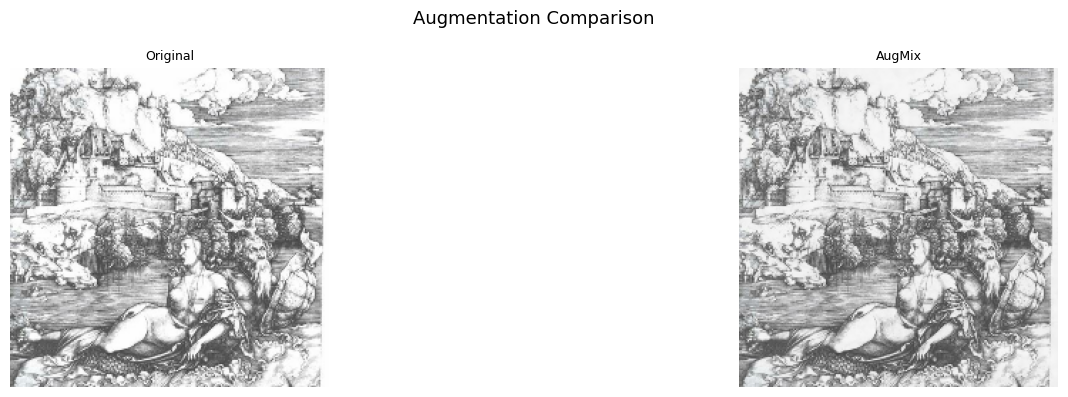

In [ ]:
# Load one sample image from your train set
sample_path = train_path  # already defined earlier
for artist in os.listdir(sample_path):
    artist_folder = os.path.join(sample_path, artist)
    if os.path.isdir(artist_folder):
        first_image = os.path.join(artist_folder, os.listdir(artist_folder)[0])
        break

# Read and prepare the image
img = tf.io.read_file(first_image)
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.resize(img, [224, 224])
img = tf.cast(img, tf.float32)

# Define your augmentations
augmentations = {
    "Original": None,
    "AugMix": keras.layers.AugMix(
    chain_depth=3,
    factor=0.3,
    alpha=1.0,
    all_ops=True,
    interpolation="bilinear",
    seed=None,
    data_format=None,),
    # "RandomFlip": keras.layers.RandomFlip("horizontal"),
    # "RandomRotation": keras.layers.RandomRotation(0.2),
    # "RandomZoom": keras.layers.RandomZoom(0.2),
    # "RandomBrightness": keras.layers.RandomBrightness(0.3),
    # "RandomContrast": keras.layers.RandomContrast(0.3),
}

# Plot original vs each augmentation
plt.figure(figsize=(18, 4))
for i, (name, layer) in enumerate(augmentations.items()):
    plt.subplot(1, len(augmentations), i + 1)
    if layer is None:
        plt.imshow(img.numpy().astype("uint8"))
    else:
        aug_img = layer(tf.expand_dims(img, 0))[0]
        plt.imshow(aug_img.numpy().astype("uint8"))
    plt.title(name, fontsize=9)
    plt.axis("off")

plt.suptitle("Augmentation Comparison", fontsize=13)
plt.tight_layout()
plt.show()

## Base

In [17]:
IMG_SIZE    = (256, 256)
BATCH_SIZE  = 32
EPOCHS      = 50
NUM_CLASSES = len(os.listdir(train_path))  # auto-detects number of artists

In [18]:
#  Data loading 
train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

val_ds = keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 9322 files belonging to 23 classes.
Found 1991 files belonging to 23 classes.
Found 2020 files belonging to 23 classes.


In [19]:
# ── Augmentation ───────────────────────────────────────────────────────────────
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.3),
    layers.AugMix(value_range=(0, 255)),
], name="augmentation")

AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(train_ds.class_names)
print(f"Number of classes: {NUM_CLASSES}")

train_ds = train_ds.map(lambda x, y: (augmentation(x), tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)

# train_ds = train_ds.map(lambda x, y: (augmentation(x), y)).prefetch(AUTOTUNE)
# val_ds   = val_ds.prefetch(AUTOTUNE)
# test_ds  = test_ds.prefetch(AUTOTUNE)

# ── Model ──────────────────────────────────────────────────────────────────────
base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False

inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# ── Compile ────────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",  
    metrics=[keras.metrics.F1Score(average="weighted")]
)

model.summary()

# ── Callbacks ──────────────────────────────────────────────────────────────────
callbacks = [
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_f1_score"),  
    CSVLogger("training_log.csv"),
    EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss"),
    ReduceLROnPlateau(factor=0.5, patience=4, monitor="val_loss", verbose=1)
]

# ── Train ──────────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ── Evaluate ───────────────────────────────────────────────────────────────────
test_loss, test_f1 = model.evaluate(test_ds)  
print(f"\nTest F1: {test_f1:.4f}")

Number of classes: 23


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,084,154 (15.58 MB)

 Trainable params: 32,023 (125.09 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/50


KeyboardInterrupt: 

In [ ]:
max(val_f1_score)

0.6834985017776489

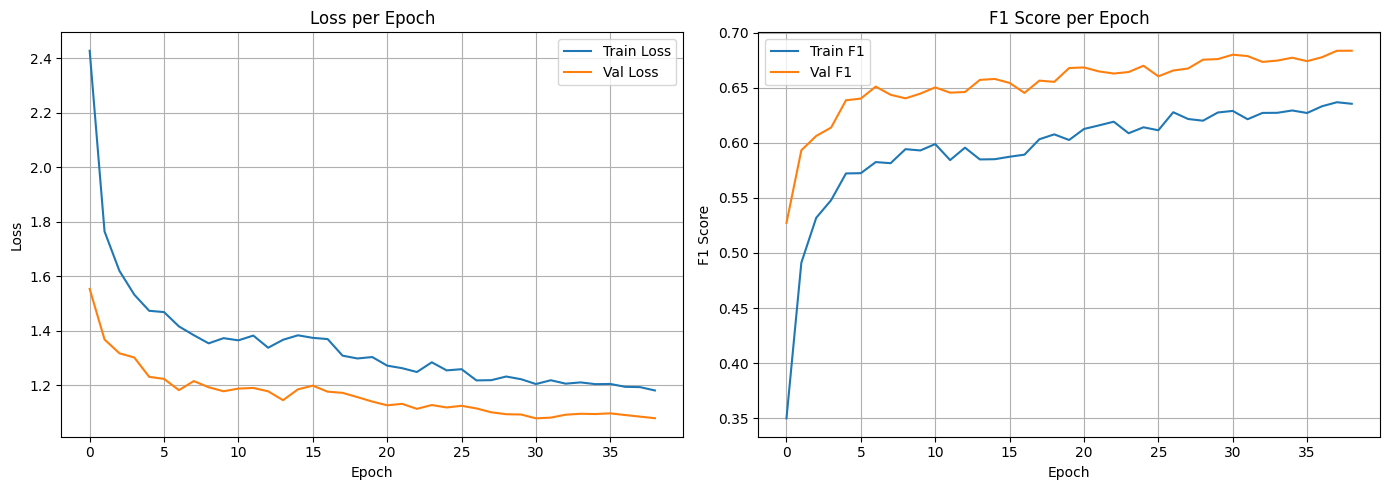

In [ ]:
def metrics(history):
    f1_score     = history.history["f1_score"]
    loss         = history.history["loss"]
    val_f1_score = history.history["val_f1_score"]
    val_loss     = history.history["val_loss"]
    learning_rate = history.history.get("lr", None)  # only exists if ReduceLROnPlateau is used
    
    return f1_score, loss, val_f1_score, val_loss, learning_rate


def model_progress(history):
    f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    #Loss 
    axes[0].plot(loss,     label="Train Loss")
    axes[0].plot(val_loss, label="Val Loss")
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    #F1 
    axes[1].plot(f1_score,     label="Train F1")
    axes[1].plot(val_f1_score, label="Val F1")
   
    axes[1].set_title("F1 Score per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].legend()
    axes[1].grid(True)


#Usage 
f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
model_progress(history)

## Efficient 

In [20]:
IMG_SIZE_1=(224,224)
BATCH_SIZE  = 32
EPOCHS      = 40
NUM_CLASSES = len(os.listdir(train_path))  # auto-detects number of artists


In [21]:
#  Data loading 
train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=True, # so thge nn learns better
    seed=123
)

val_ds = keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 9322 files belonging to 23 classes.
Found 1991 files belonging to 23 classes.
Found 2020 files belonging to 23 classes.


In [22]:
labels = []

for _, y in train_ds:
    labels.extend(y.numpy())

labels = np.array(labels)

class_counts = Counter(labels)
print("Class counts:", class_counts)

total_samples = len(labels)
num_classes = len(class_counts)

class_weights = {int(cls): total_samples / (num_classes * count) 
                 for cls, count in class_counts.items()}

print("\nClass weights:")
for k, v in class_weights.items():
    print(f"{k}: {v:.4f}")

Class counts: Counter({np.int32(22): 924, np.int32(14): 891, np.int32(17): 682, np.int32(4): 653, np.int32(18): 450, np.int32(2): 434, np.int32(0): 406, np.int32(11): 384, np.int32(20): 380, np.int32(12): 375, np.int32(15): 373, np.int32(7): 369, np.int32(1): 310, np.int32(5): 298, np.int32(16): 284, np.int32(9): 282, np.int32(13): 282, np.int32(6): 272, np.int32(3): 267, np.int32(8): 264, np.int32(10): 254, np.int32(19): 253, np.int32(21): 235})

Class weights:
1: 1.3074
20: 1.0666
18: 0.9007
14: 0.4549
4: 0.6207
5: 1.3601
6: 1.4901
21: 1.7247
9: 1.4372
22: 0.4386
7: 1.0984
2: 0.9339
11: 1.0555
12: 1.0808
17: 0.5943
8: 1.5352
0: 0.9983
13: 1.4372
10: 1.5957
15: 1.0866
19: 1.6020
3: 1.5180
16: 1.4271


In [21]:
import keras_cv

c:\Users\carlo\Nova pasta\envs\fall_dm2025\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [83]:
#Augmentation 
pipe_augment = keras_cv.layers.RandomAugmentationPipeline(
    layers=[
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.1),
        keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
        layers.RandomBrightness(factor=0.1),
        layers.RandomContrast(factor=0.1),
        # layers.RandomCrop(226, 226),
    ],
    augmentations_per_image=3,
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (pipe_augment(x), tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)

TypeError: in user code:

    File "C:\Users\carlo\AppData\Local\Temp\ipykernel_26640\355083695.py", line 17, in None  *
        lambda x, y: (pipe_augment(x), tf.one_hot(y, NUM_CLASSES))

    TypeError: Value passed to parameter 'indices' has DataType float32 not in list of allowed values: uint8, int8, int32, int64


In [47]:

# print(f"Number of classes: {NUM_CLASSES}")

# train_ds = train_ds.map(lambda x, y: (pipe_augment(x), y)).prefetch(AUTOTUNE)
# val_ds   = val_ds.prefetch(AUTOTUNE)
# test_ds  = test_ds.prefetch(AUTOTUNE)

#Model 
base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE_1, 3)
)
base_model.trainable = False

inputs  = keras.Input(shape=(*IMG_SIZE_1, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

#  Compile 
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",  
    metrics=[keras.metrics.F1Score(average="macro")]
)

model.summary()

# ── Callbacks ──────────────────────────────────────────────────────────────────
callbacks = [
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_f1_score", mode="max"),  
    CSVLogger("training_log.csv"),
    EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss"),
    ReduceLROnPlateau(factor=0.5, patience=4, monitor="val_loss", verbose=1)
]

# ── Train ──────────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights 
)

# ── Evaluate ───────────────────────────────────────────────────────────────────
test_loss, test_f1 = model.evaluate(test_ds)  
print(f"\nTest F1: {test_f1:.4f}")

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,084,154 (15.58 MB)

 Trainable params: 32,023 (125.09 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 276s 923ms/step - f1_score: 0.3291 - loss: 2.4343 - val_f1_score: 0.5446 - val_loss: 1.4454 - learning_rate: 0.0010
Epoch 2/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 202s 687ms/step - f1_score: 0.4834 - loss: 1.7212 - val_f1_score: 0.6007 - val_loss: 1.2811 - learning_rate: 0.0010
Epoch 3/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 202s 690ms/step - f1_score: 0.5360 - loss: 1.5463 - val_f1_score: 0.6294 - val_loss: 1.1992 - learning_rate: 0.0010
Epoch 4/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 208s 712ms/step - f1_score: 0.5534 - loss: 1.4604 - val_f1_score: 0.6423 - val_loss: 1.1418 - learning_rate: 0.0010
Epoch 5/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 204s 696ms/step - f1_score: 0.5770 - loss: 1.3718 - val_f1_score: 0.6614 - val_loss: 1.1355 - learning_rate: 0.0010
Epoch 6/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 198s 676ms/step - f1_score: 0.5837 - loss: 1.3526 - val_f1_score: 0.6481 - val_loss: 1.1384 - learning_rate: 0.0010
Epoch 7/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 195s 666ms/step - f1_sco

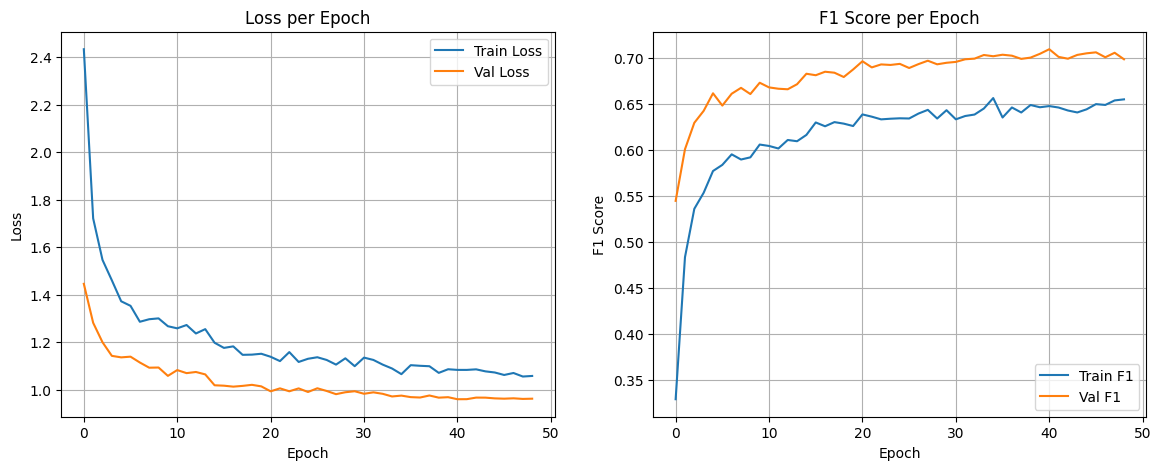

In [48]:
def metrics(history):
    f1_score     = history.history["f1_score"]
    loss         = history.history["loss"]
    val_f1_score = history.history["val_f1_score"]
    val_loss     = history.history["val_loss"]
    learning_rate = history.history.get("lr", None)  # only exists if ReduceLROnPlateau is used
    
    return f1_score, loss, val_f1_score, val_loss, learning_rate


def model_progress(history):
    f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    #Loss 
    axes[0].plot(loss,     label="Train Loss")
    axes[0].plot(val_loss, label="Val Loss")
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    #F1 
    axes[1].plot(f1_score,     label="Train F1")
    axes[1].plot(val_f1_score, label="Val F1")
   
    axes[1].set_title("F1 Score per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].legend()
    axes[1].grid(True)


#Usage 
f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
model_progress(history)

## Eficient v2

In [11]:
#Augmentation 

pipe_augment = keras.Sequential(
        [layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        layers.RandomBrightness(factor=0.05),
        layers.RandomContrast(factor=0.1)],
        name="augmentation"
    
)



AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)

In [82]:
# ── Model ──────────────────────────────────────────────────────────────────────
base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE_1, 3)
)
base_model.trainable = False   # ← frozen for phase 1

inputs  = keras.Input(shape=(*IMG_SIZE_1, 3))
x       = pipe_augment(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# ── Phase 1: Head only ────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[keras.metrics.F1Score(average="macro")]
)

callbacks_p1 = [
    ModelCheckpoint("best_p1.keras", save_best_only=True,
                    monitor="val_f1_score", mode="max"),
    CSVLogger("log_p1.csv"),
    EarlyStopping(patience=8, restore_best_weights=True,
                  monitor="val_f1_score", mode="max"),
    ReduceLROnPlateau(factor=0.5, patience=4,
                      monitor="val_f1_score", mode="max", verbose=1)
]

model.fit(train_ds, validation_data=val_ds, epochs=30,
          callbacks=callbacks_p1, class_weight=class_weights)

# ── Phase 2: Fine-tune backbone ───────────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[keras.metrics.F1Score(average="macro")]
)

callbacks_p2 = [
    ModelCheckpoint("best_model.keras", save_best_only=True,
                    monitor="val_f1_score", mode="max"),
    CSVLogger("log_p2.csv"),
    EarlyStopping(patience=8, restore_best_weights=True,
                  monitor="val_f1_score", mode="max"),
    ReduceLROnPlateau(factor=0.5, patience=4,
                      monitor="val_f1_score", mode="max", verbose=1)
]

model.fit(train_ds, validation_data=val_ds, epochs=30,
          callbacks=callbacks_p2, class_weight=class_weights)

# ── Evaluate ───────────────────────────────────────────────────────────────────
test_loss, test_f1 = model.evaluate(test_ds)
print(f"\nTest F1: {test_f1:.4f}")

Epoch 1/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - f1_score: 0.3863 - loss: 2.1467 - val_f1_score: 0.5417 - val_loss: 1.4780 - learning_rate: 0.0010
Epoch 2/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 486s 1s/step - f1_score: 0.5208 - loss: 1.5409 - val_f1_score: 0.5888 - val_loss: 1.3332 - learning_rate: 0.0010
Epoch 3/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 458s 2s/step - f1_score: 0.5623 - loss: 1.3850 - val_f1_score: 0.6100 - val_loss: 1.2400 - learning_rate: 0.0010
Epoch 4/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 465s 2s/step - f1_score: 0.5943 - loss: 1.2739 - val_f1_score: 0.6176 - val_loss: 1.2071 - learning_rate: 0.0010
Epoch 5/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 527s 2s/step - f1_score: 0.6019 - loss: 1.2304 - val_f1_score: 0.6195 - val_loss: 1.1921 - learning_rate: 0.0010
Epoch 6/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 587s 2s/step - f1_score: 0.6214 - loss: 1.1663 - val_f1_score: 0.6200 - val_loss: 1.1966 - learning_rate: 0.0010
Epoch 7/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1194s 4s/step - f1_score: 0.6250 - loss: 1

KeyboardInterrupt: 

## Efficient v3

In [85]:
#Augmentation 
pipe_augment = keras.Sequential(
        [layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        layers.RandomBrightness(factor=0.05),
        layers.RandomContrast(factor=0.1)],
        name="augmentation"
    
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)

In [86]:
# ── Model ──────────────────────────────────────────────────────────────────────
base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE_1, 3)
)
base_model.trainable = False   # ← frozen for phase 1

inputs  = keras.Input(shape=(*IMG_SIZE_1, 3))
x       = pipe_augment(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# ── Phase 1: Head only ────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[keras.metrics.F1Score(average="macro")]
)

callbacks_p1 = [
    ModelCheckpoint("best_p1.keras", save_best_only=True,
                    monitor="val_f1_score", mode="max"),
    CSVLogger("log_p1.csv"),
    EarlyStopping(patience=8, restore_best_weights=True,
                  monitor="val_f1_score", mode="max"),
    ReduceLROnPlateau(factor=0.5, patience=4,
                      monitor="val_f1_score", mode="max", verbose=1)
]

model.fit(train_ds, validation_data=val_ds, epochs=30,
          callbacks=callbacks_p1, class_weight=class_weights)

# ── Phase 2: Fine-tune backbone ───────────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[keras.metrics.F1Score(average="macro")]
)

callbacks_p2 = [
    ModelCheckpoint("best_model.keras", save_best_only=True,
                    monitor="val_f1_score", mode="max"),
    CSVLogger("log_p2.csv"),
    EarlyStopping(patience=8, restore_best_weights=True,
                  monitor="val_f1_score", mode="max"),
    ReduceLROnPlateau(factor=0.5, patience=4,
                      monitor="val_f1_score", mode="max", verbose=1)
]

model.fit(train_ds, validation_data=val_ds, epochs=40,
          callbacks=callbacks_p2, class_weight=class_weights)

# ── Evaluate ───────────────────────────────────────────────────────────────────
test_loss, test_f1 = model.evaluate(test_ds)
print(f"\nTest F1: {test_f1:.4f}")

Epoch 1/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 767s 3s/step - f1_score: 0.3770 - loss: 2.1734 - val_f1_score: 0.5557 - val_loss: 1.4635 - learning_rate: 0.0010
Epoch 2/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 419s 1s/step - f1_score: 0.5109 - loss: 1.5633 - val_f1_score: 0.5902 - val_loss: 1.3294 - learning_rate: 0.0010
Epoch 3/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 4942s 17s/step - f1_score: 0.5572 - loss: 1.3951 - val_f1_score: 0.6093 - val_loss: 1.2661 - learning_rate: 0.0010
Epoch 4/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 198s 677ms/step - f1_score: 0.5941 - loss: 1.2980 - val_f1_score: 0.6217 - val_loss: 1.2210 - learning_rate: 0.0010
Epoch 5/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - f1_score: 0.5988 - loss: 1.2412 - val_f1_score: 0.6222 - val_loss: 1.2192 - learning_rate: 0.0010
Epoch 6/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 153s 521ms/step - f1_score: 0.6147 - loss: 1.1928 - val_f1_score: 0.6271 - val_loss: 1.1857 - learning_rate: 0.0010
Epoch 7/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 344s 1s/step - f1_score: 0.6251 - 

In [ ]:
def metrics(history):
    f1_score     = history.history["f1_score"]
    loss         = history.history["loss"]
    val_f1_score = history.history["val_f1_score"]
    val_loss     = history.history["val_loss"]
    learning_rate = history.history.get("lr", None)  # only exists if ReduceLROnPlateau is used
    
    return f1_score, loss, val_f1_score, val_loss, learning_rate


def model_progress(history):
    f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    #Loss 
    axes[0].plot(loss,     label="Train Loss")
    axes[0].plot(val_loss, label="Val Loss")
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    #F1 
    axes[1].plot(f1_score,     label="Train F1")
    axes[1].plot(val_f1_score, label="Val F1")
   
    axes[1].set_title("F1 Score per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].legend()
    axes[1].grid(True)


#Usage 
f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
model_progress(history)

## VGG19

In [ ]:
IMG_SIZE_1=(224,224)
BATCH_SIZE  = 32
EPOCHS      = 40
NUM_CLASSES = len(os.listdir(train_path))  # auto-detects number of artists

In [88]:
#  Data loading 
train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=True, # so thge nn learns better
    seed=123
)

val_ds = keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 9322 files belonging to 23 classes.
Found 1991 files belonging to 23 classes.
Found 2020 files belonging to 23 classes.


In [89]:
#Augmentation 
pipe_augment = keras.Sequential(
        [layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        layers.RandomBrightness(factor=0.05),
        layers.RandomContrast(factor=0.1)],
        name="augmentation"
    
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)

In [90]:
# ── Model ──────────────────────────────────────────────────────────────────────
base_model = keras.applications.VGG19(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE_1, 3)
)
base_model.trainable = False   # ← frozen for phase 1

inputs  = keras.Input(shape=(*IMG_SIZE_1, 3))
x       = pipe_augment(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# ── Phase 1: Head only ────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[keras.metrics.F1Score(average="macro")]
)

callbacks_p1 = [
    ModelCheckpoint("best_p1.keras", save_best_only=True,
                    monitor="val_f1_score", mode="max"),
    CSVLogger("log_p1.csv"),
    EarlyStopping(patience=8, restore_best_weights=True,
                  monitor="val_f1_score", mode="max"),
    ReduceLROnPlateau(factor=0.5, patience=4,
                      monitor="val_f1_score", mode="max", verbose=1)
]

model.fit(train_ds, validation_data=val_ds, epochs=30,
          callbacks=callbacks_p1, class_weight=class_weights)

# ── Phase 2: Fine-tune backbone ───────────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[keras.metrics.F1Score(average="macro")]
)

callbacks_p2 = [
    ModelCheckpoint("best_model.keras", save_best_only=True,
                    monitor="val_f1_score", mode="max"),
    CSVLogger("log_p2.csv"),
    EarlyStopping(patience=8, restore_best_weights=True,
                  monitor="val_f1_score", mode="max"),
    ReduceLROnPlateau(factor=0.5, patience=4,
                      monitor="val_f1_score", mode="max", verbose=1)
]

model.fit(train_ds, validation_data=val_ds, epochs=40,
          callbacks=callbacks_p2, class_weight=class_weights)

# ── Evaluate ───────────────────────────────────────────────────────────────────
test_loss, test_f1 = model.evaluate(test_ds)
print(f"\nTest F1: {test_f1:.4f}")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 74s 1us/step
Epoch 1/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1723s 6s/step - f1_score: 0.2907 - loss: 2.5256 - val_f1_score: 0.4656 - val_loss: 1.7695 - learning_rate: 0.0010
Epoch 2/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1846s 6s/step - f1_score: 0.4097 - loss: 1.9291 - val_f1_score: 0.5014 - val_loss: 1.6139 - learning_rate: 0.0010
Epoch 3/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1655s 6s/step - f1_score: 0.4460 - loss: 1.7838 - val_f1_score: 0.5363 - val_loss: 1.5261 - learning_rate: 0.0010
Epoch 4/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1734s 6s/step - f1_score: 0.4748 - loss: 1.6603 - val_f1_score: 0.5273 - val_loss: 1.5010 - learning_rate: 0.0010
Epoch 5/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1712s 6s/step - f1_score: 0.4832 - loss: 1.6099 - val_f1_score: 0.5304 - val_loss: 1.4855 - learning_rate: 0.0010
Epoch 6/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1697s 6s/step - f1_score: 0.4955 - loss: 1.5971 - val_f1_score: 0.5513 - val_loss: 1.4218 - learning_rate: 0.0010
Epoch 7/30
292/292 ━━━━━

KeyboardInterrupt: 

In [ ]:
def metrics(history):
    f1_score     = history.history["f1_score"]
    loss         = history.history["loss"]
    val_f1_score = history.history["val_f1_score"]
    val_loss     = history.history["val_loss"]
    learning_rate = history.history.get("lr", None)  # only exists if ReduceLROnPlateau is used
    
    return f1_score, loss, val_f1_score, val_loss, learning_rate


def model_progress(history):
    f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    #Loss 
    axes[0].plot(loss,     label="Train Loss")
    axes[0].plot(val_loss, label="Val Loss")
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    #F1 
    axes[1].plot(f1_score,     label="Train F1")
    axes[1].plot(val_f1_score, label="Val F1")
   
    axes[1].set_title("F1 Score per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].legend()
    axes[1].grid(True)


#Usage 
f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
model_progress(history)

## EfficientB2

In [23]:
IMG_SIZE_1=(260,260)
BATCH_SIZE  = 32
EPOCHS      = 40
NUM_CLASSES = len(os.listdir(train_path))  # auto-detects number of artists

In [24]:
#  Data loading 
train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=True, # so thge nn learns better
    seed=123
)

val_ds = keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 9322 files belonging to 23 classes.
Found 1991 files belonging to 23 classes.
Found 2020 files belonging to 23 classes.


In [25]:
pipe_augment = keras.Sequential(
        [layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        layers.RandomBrightness(factor=0.05),
        layers.RandomContrast(factor=0.1)],
        name="augmentation"
    
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)

In [ ]:
# ── Model ──────────────────────────────────────────────────────────────────────
base_model = keras.applications.EfficientNetB2(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE_1, 3)
)
base_model.trainable = False   # ← frozen for phase 1

inputs  = keras.Input(shape=(*IMG_SIZE_1, 3))
x       = pipe_augment(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# ── Phase 1: Head only ────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[keras.metrics.F1Score(average="macro")]
)

callbacks_p1 = [
    ModelCheckpoint("best_p1.keras", save_best_only=True,
                    monitor="val_f1_score", mode="max"),
    CSVLogger("log_p1.csv"),
    EarlyStopping(patience=8, restore_best_weights=True,
                  monitor="val_loss"),
    ReduceLROnPlateau(factor=0.5, patience=4,
                      monitor="val_f1_score", mode="max", verbose=1)
]

history_p1_EfficientNetB2= model.fit(train_ds, validation_data=val_ds, epochs=30,
          callbacks=callbacks_p1, class_weight=class_weights)

# ── Phase 2: Fine-tune backbone ───────────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[keras.metrics.F1Score(average="macro")]
)

callbacks_p2 = [
    ModelCheckpoint("best_model.keras", save_best_only=True,
                    monitor="val_f1_score", mode="max"),
    CSVLogger("log_p2.csv"),
    EarlyStopping(patience=8, restore_best_weights=True,
                  monitor="val_loss"),
    ReduceLROnPlateau(factor=0.5, patience=4,
                      monitor="val_f1_score", mode="max", verbose=1)
]

history_p2_EfficientNetB2= model.fit(train_ds, validation_data=val_ds, epochs=40,
          callbacks=callbacks_p2, class_weight=class_weights)

# ── Evaluate ───────────────────────────────────────────────────────────────────
test_loss, test_f1 = model.evaluate(test_ds)
print(f"\nTest F1: {test_f1:.4f}")

Epoch 1/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 280s 932ms/step - f1_score: 0.3711 - loss: 2.1689 - val_f1_score: 0.5231 - val_loss: 1.5907 - learning_rate: 0.0010
Epoch 2/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - f1_score: 0.5070 - loss: 1.5655 - val_f1_score: 0.5868 - val_loss: 1.3557 - learning_rate: 0.0010
Epoch 3/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 1512s 5s/step - f1_score: 0.5542 - loss: 1.4194 - val_f1_score: 0.5989 - val_loss: 1.2998 - learning_rate: 0.0010
Epoch 4/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 307s 904ms/step - f1_score: 0.5794 - loss: 1.3180 - val_f1_score: 0.6268 - val_loss: 1.2109 - learning_rate: 0.0010
Epoch 5/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - f1_score: 0.5934 - loss: 1.2659 - val_f1_score: 0.6233 - val_loss: 1.1955 - learning_rate: 0.0010
Epoch 6/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - f1_score: 0.6089 - loss: 1.2070 - val_f1_score: 0.6394 - val_loss: 1.1774 - learning_rate: 0.0010
Epoch 7/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - f1_score: 0.6190 - l

In [ ]:
def metrics(history):
    # check keys first and adjust if needed
    f1_key = "f1_score" if "f1_score" in history.history else "macro_f1_score"
    
    f1_score      = history.history[f1_key]
    loss          = history.history["loss"]
    val_f1_score  = history.history[f"val_{f1_key}"]
    val_loss      = history.history["val_loss"]
    learning_rate = history.history.get("lr", None)
    
    return f1_score, loss, val_f1_score, val_loss, learning_rate


def model_progress(history):
    f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    #Loss 
    axes[0].plot(loss,     label="Train Loss")
    axes[0].plot(val_loss, label="Val Loss")
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")p
    axes[0].legend()
    axes[0].grid(True)

    #F1 
    axes[1].plot(f1_score,     label="Train F1")
    axes[1].plot(val_f1_score, label="Val F1")
   
    axes[1].set_title("F1 Score per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].legend()
    axes[1].grid(True)




# ── Plot Phase 1 ───────────────────────────────────────────────────────────────
print("Phase 1 - Head only training:")
model_progress(history_p1_EfficientNetB2)

# ── Plot Phase 2 ───────────────────────────────────────────────────────────────
print("Phase 2 - Fine-tuning:")
model_progress(history_p2_EfficientNetB2)

Phase 1 - Head only training:


NameError: name 'history_p1_EfficientNetB2' is not defined

## ConvNeXt

In [ ]:
IMG_SIZE_1=(224,224)
BATCH_SIZE  = 32
EPOCHS      = 40
NUM_CLASSES = len(os.listdir(train_path))  # auto-detects number of artists

In [ ]:
#  Data loading 
train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=True, # so thge nn learns better
    seed=123
)

val_ds = keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE_1,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Pipeline

In [ ]:
#Augmentation 
pipe_augment = keras_cv.layers.RandomAugmentationPipeline(
    layers=[
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.1),
        keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
        layers.RandomBrightness(factor=0.1),
        layers.RandomContrast(factor=0.1),
        # layers.RandomCrop(226, 226),
    ],
    augmentations_per_image=3,
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (pipe_augment(x), tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))).prefetch(AUTOTUNE)

In [49]:


base_model= keras.applications.ConvNeXtTiny(
    include_top=False,
    include_preprocessing=True, #normalization type of shit VER
    weights="imagenet",
    input_tensor=None,
    input_shape=(*IMG_SIZE_1, 3),
    pooling=None
)




base_model.trainable = False

inputs  = keras.Input(shape=(*IMG_SIZE_1, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

#  Compile 
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",  
    metrics=[keras.metrics.F1Score(average="macro")]
)

model.summary()

# ── Callbacks ──────────────────────────────────────────────────────────────────
callbacks = [
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_f1_score", mode="max"),  
    CSVLogger("training_log.csv"),
    EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss"),
    ReduceLROnPlateau(factor=0.5, patience=4, monitor="val_loss", verbose=1)
]

# ── Train ──────────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights 
)

# ── Evaluate ───────────────────────────────────────────────────────────────────
test_loss, test_f1 = model.evaluate(test_ds)  
print(f"\nTest F1: {test_f1:.4f}")


111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 52s 0us/step


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 23)             │        17,687 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,840,887 (106.20 MB)

 Trainable params: 19,223 (75.09 KB)

 Non-trainable params: 27,821,664 (106.13 MB)

Epoch 1/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 2573s 9s/step - f1_score: 0.3080 - loss: 2.5158 - val_f1_score: 0.5368 - val_loss: 1.5749 - learning_rate: 0.0010
Epoch 2/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 2139s 7s/step - f1_score: 0.5060 - loss: 1.6501 - val_f1_score: 0.6276 - val_loss: 1.2099 - learning_rate: 0.0010
Epoch 3/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 2096s 7s/step - f1_score: 0.5510 - loss: 1.4439 - val_f1_score: 0.6609 - val_loss: 1.0844 - learning_rate: 0.0010
Epoch 4/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 1871s 6s/step - f1_score: 0.5832 - loss: 1.3438 - val_f1_score: 0.6812 - val_loss: 1.0104 - learning_rate: 0.0010
Epoch 5/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 1737s 6s/step - f1_score: 0.5977 - loss: 1.2883 - val_f1_score: 0.6883 - val_loss: 0.9753 - learning_rate: 0.0010
Epoch 6/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 1712s 6s/step - f1_score: 0.6010 - loss: 1.2528 - val_f1_score: 0.6886 - val_loss: 0.9762 - learning_rate: 0.0010
Epoch 7/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 1726s 6s/step - f1_score: 0.6144 - l

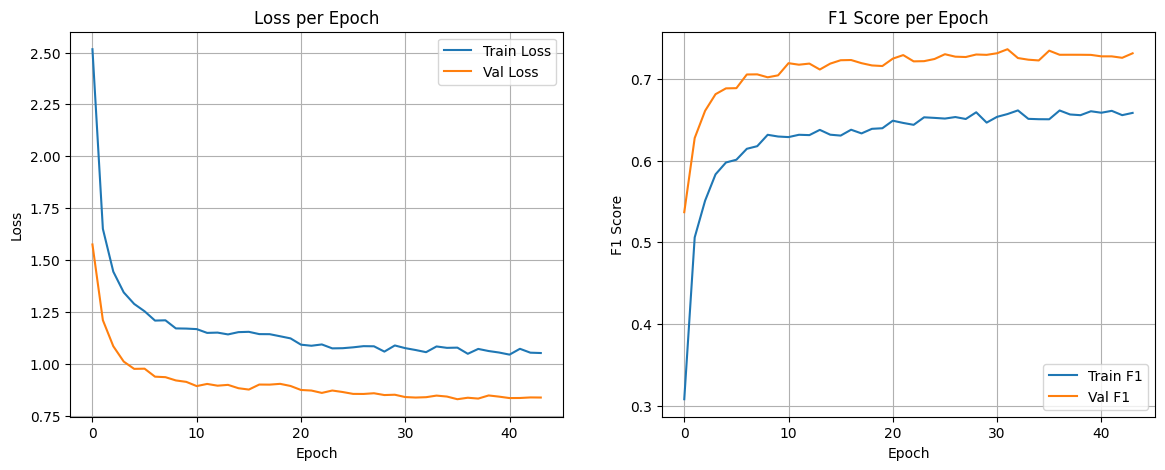

In [50]:
def metrics(history):
    f1_score     = history.history["f1_score"]
    loss         = history.history["loss"]
    val_f1_score = history.history["val_f1_score"]
    val_loss     = history.history["val_loss"]
    learning_rate = history.history.get("lr", None)  # only exists if ReduceLROnPlateau is used
    
    return f1_score, loss, val_f1_score, val_loss, learning_rate


def model_progress(history):
    f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    #Loss 
    axes[0].plot(loss,     label="Train Loss")
    axes[0].plot(val_loss, label="Val Loss")
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    #F1 
    axes[1].plot(f1_score,     label="Train F1")
    axes[1].plot(val_f1_score, label="Val F1")
   
    axes[1].set_title("F1 Score per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].legend()
    axes[1].grid(True)


#Usage 
f1_score, loss, val_f1_score, val_loss, learning_rate = metrics(history)
model_progress(history)

## Tretas

In [ ]:
#Create TensorFlow Dataset objects
train_ds_rand = (
    train_ds
    .map(
        lambda x, y: (rand_augment(tf.cast(x, tf.uint8)), y),
        num_parallel_calls=AUTO,
    )
    .prefetch(AUTO)
)


val_ds = val_ds.prefetch(AUTO)
test_ds = test_ds.prefetch(AUTO)

In [ ]:
simple_aug = keras.Sequential(
    [
       layers.RandomFlip("horizontal"),
        # layers.RandomFlip("vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.1),
        keras.layers.RandomTranslation(
            height_factor=0.2,
            width_factor=0.2),
        # layers.AugMix(value_range=(0, 255)),
        layers.RandomBrightness(factor=0.1),
        layers.RandomContrast(factor=0.1),
        layers.RandomCrop(226,226),
    ]
)

# Now, map the augmentation pipeline to our training dataset

train_ds_simple = (
    train_ds
    .map(lambda x, y: (simple_aug(x), y), num_parallel_calls=AUTO)
    .prefetch(AUTO)
)

In [ ]:
sample_images, _ = next(iter(train_ds_rand))
plt.figure(figsize=(10, 10))
for i, image in enumerate(sample_images[:9]):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy().astype("int"))
    plt.axis("off")


# VER DISTO

In [ ]:
preprocessing_pipeline = layers.Pipeline([
    layers.AutoContrast(),
    layers.RandomZoom(0.2),
    layers.RandomRotation(0.2),
])